# Flow Map 101

This notebook explains the basic idea behind **flow maps**: instead of asking a
neural network for a tiny local velocity step, we ask it to jump from one time
on a generative path to another time on the same path.

We will use a tiny 2D example that runs on CPU:

1. train a normal flow-matching velocity model on an 8-mode ring,
2. define a flow map $F_\phi(x_s, s, t)$ as a finite-time jump operator,
3. introduce semigroup, Lagrangian, and Eulerian consistency,
4. train teacher-distilled flow maps with local teacher velocity targets,
5. train self-distilled flow maps directly from data,
6. compare all methods with 1, 2, 4, and 8 NFE sampling,
7. show how ITM-style reward tilting can be trained together with flow-map
   consistency in one stage.

This tutorial is inspired by recent flow-map papers, especially
[Boffi et al.'s **Flow Map Matching** framework](https://arxiv.org/abs/2406.07507)
and their official
[`flow-maps` codebase](https://github.com/nmboffi/flow-maps),
Sander Dieleman's
[flow-map overview](https://sander.ai/2026/05/06/flow-maps.html), and the
[ICLR Blogpost on flow-map learning](https://iclr-blogposts.github.io/2026/blog/2026/flow-map-learning/).

Edit History:
- 06-23-2026: initial version

## 0. Setup

We only use `torch`, `numpy`, `matplotlib`, `tqdm`, and notebook display
utilities. The example is deliberately small: 2D points, small MLPs, and a few
seconds of CPU training.

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import Markdown, display

torch.manual_seed(0)
np.random.seed(0)
torch.set_default_dtype(torch.float32)

SHOW_PROGRESS = False


def display_markdown_table(headers, rows):
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    lines.extend("| " + " | ".join(str(x) for x in row) + " |" for row in rows)
    display(Markdown("\n".join(lines)))


print("torch:", torch.__version__)

torch: 2.11.0


We first define the toy distribution and a few plotting / metric helpers. The
target data distribution is the same kind of 8-mode ring we used in the
[RAM](https://xing-mei.github.io/notes/ram-tutorial.html) and
[ITM](https://xing-mei.github.io/notes/tilt_matching_tutorial.html) notebooks.

In [2]:
def ring_centers(modes: int = 8, radius: float = 4.0):
    angles = torch.arange(modes) * (2 * math.pi / modes)
    return torch.stack([radius * torch.cos(angles), radius * torch.sin(angles)], dim=-1)


def sample_ring(
    n: int,
    *,
    modes: int = 8,
    radius: float = 4.0,
    sigma: float = 0.15,
    return_labels: bool = False,
):
    labels = torch.randint(0, modes, (n,))
    centers = ring_centers(modes, radius)[labels]
    samples = centers + sigma * torch.randn(n, 2)
    if return_labels:
        return samples, labels
    return samples


def sample_source(n: int) -> torch.Tensor:
    return torch.randn(n, 2)


def plot_samples(
    samples,
    ax=None,
    *,
    title=None,
    color="C0",
    s=6,
    alpha=0.45,
    c=None,
    cmap=None,
    xlim=(-5, 5),
    ylim=(-5, 5),
):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    pts = samples.detach().cpu()
    if c is None:
        ax.scatter(pts[:, 0], pts[:, 1], s=s, alpha=alpha, color=color)
    else:
        ax.scatter(pts[:, 0], pts[:, 1], s=s, alpha=alpha, c=c, cmap=cmap)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    if title:
        ax.set_title(title)
    return ax


def make_grid(n_grid=75, xlim=(-5, 5), ylim=(-5, 5)):
    gx = torch.linspace(xlim[0], xlim[1], n_grid)
    gy = torch.linspace(ylim[0], ylim[1], n_grid)
    X, Y = torch.meshgrid(gx, gy, indexing="ij")
    pts = torch.stack([X.flatten(), Y.flatten()], dim=-1)
    return pts, X, Y


def kde_density(grid_pts, samples, h=0.16):
    d2 = ((grid_pts[:, None, :] - samples[None, :, :]) ** 2).sum(-1)
    return torch.exp(-0.5 * d2 / h**2).mean(-1)


def normalize_density(z):
    return z / (z.sum() + 1e-12)


def plot_density_from_samples(samples, ax=None, *, title=None, n_grid=75):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    grid, _, _ = make_grid(n_grid=n_grid)
    z = normalize_density(kde_density(grid, samples)).reshape(n_grid, n_grid)
    ax.imshow(z.T.cpu().numpy(), origin="lower", extent=(-5, 5, -5, 5), cmap="viridis")
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect("equal")
    if title:
        ax.set_title(title)
    return ax


def sliced_wasserstein(samples_a, samples_b, *, n_projections=128, seed=0):
    n = min(len(samples_a), len(samples_b))
    a = samples_a[:n]
    b = samples_b[:n]
    gen = torch.Generator().manual_seed(seed)
    directions = torch.randn(n_projections, 2, generator=gen)
    directions = directions / directions.norm(dim=1, keepdim=True).clamp_min(1e-12)
    pa = torch.sort(a @ directions.T, dim=0).values
    pb = torch.sort(b @ directions.T, dim=0).values
    return torch.sqrt(((pa - pb) ** 2).mean()).item()


def assign_ring_modes(x):
    centers = ring_centers().to(x)
    d2 = ((x[:, None, :] - centers[None, :, :]) ** 2).sum(-1)
    return d2.argmin(-1)


def mode_js(samples_a, samples_b, eps=1e-8):
    labels_a = assign_ring_modes(samples_a)
    labels_b = assign_ring_modes(samples_b)
    pa = torch.bincount(labels_a, minlength=8).float()
    pb = torch.bincount(labels_b, minlength=8).float()
    pa = pa / pa.sum()
    pb = pb / pb.sum()

    def kl(p, q):
        p = (p + eps) / (p.sum() + eps * p.numel())
        q = (q + eps) / (q.sum() + eps * q.numel())
        return (p * (p.log() - q.log())).sum()

    m = 0.5 * (pa + pb)
    return (0.5 * kl(pa, m) + 0.5 * kl(pb, m)).item()

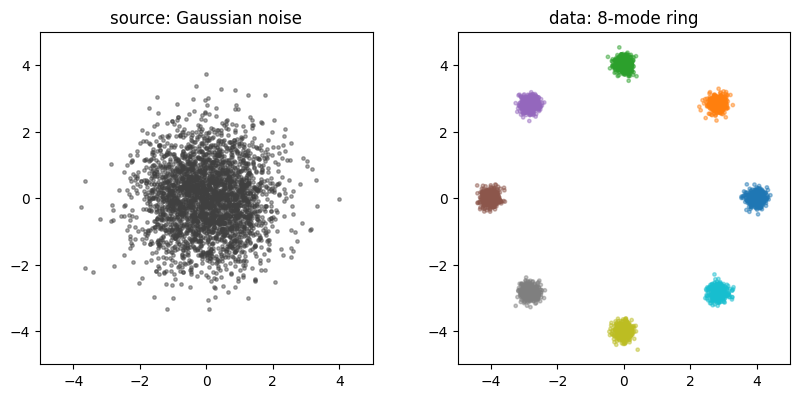

In [3]:
ring_samples, ring_labels = sample_ring(3000, return_labels=True)
noise_samples = sample_source(3000)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4))
plot_samples(noise_samples, axes[0], title="source: Gaussian noise", color="0.25")
plot_samples(
    ring_samples,
    axes[1],
    title="data: 8-mode ring",
    c=ring_labels.numpy(),
    cmap="tab10",
)
plt.tight_layout()
plt.show()

## 1. Start with a velocity field

A standard flow-matching model learns a **velocity field**:

$$
v_\theta(x_t,t).
$$

In this notebook we use the same time convention as RAM and ITM:

* $t=0$: clean data,
* $t=1$: Gaussian noise.

During training we sample a clean point $X_0$ and a noise point $\varepsilon$,
then linearly interpolate:

$$
X_t = (1-t)X_0 + t\varepsilon.
$$

The conditional path velocity is:

$$
\dot X_t = \varepsilon - X_0.
$$

The model learns the conditional average of that velocity at each location:

$$
v_\theta(x,t) \approx \mathbb{E}[\varepsilon-X_0 \mid X_t=x].
$$

To generate samples, we start from noise at $t=1$ and repeatedly take small
Euler steps back to $t=0$.

In [4]:
class TimeEmbedding(nn.Module):
    def __init__(self, n_freqs: int = 8):
        super().__init__()
        self.register_buffer("freqs", 2 ** torch.arange(n_freqs).float() * math.pi)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        angles = t[:, None] * self.freqs[None, :]
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


class VelocityNet(nn.Module):
    def __init__(self, hidden: int = 192, n_freqs: int = 8):
        super().__init__()
        self.time_emb = TimeEmbedding(n_freqs)
        in_dim = 2 + 2 * n_freqs
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([x, self.time_emb(t)], dim=-1))


def num_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


def train_flow_matching(
    model: VelocityNet,
    *,
    steps: int = 8000,
    batch_size: int = 256,
    lr: float = 1e-3,
):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    pbar = tqdm(range(steps), desc="teacher flow matching", disable=not SHOW_PROGRESS, leave=False)
    for step in pbar:
        x0 = sample_ring(batch_size)
        eps = sample_source(batch_size)
        t = torch.rand(batch_size)
        xt = (1 - t[:, None]) * x0 + t[:, None] * eps
        target = eps - x0

        pred = model(xt, t)
        loss = ((pred - target) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()

        losses.append(loss.item())
    return losses


@torch.no_grad()
def euler_sample_velocity(
    model: VelocityNet,
    start: torch.Tensor,
    *,
    n_steps: int = 250,
):
    model.eval()
    x = start.clone()
    n = x.shape[0]
    dt = 1.0 / n_steps
    for k in range(n_steps):
        t = torch.full((n,), 1.0 - k * dt)
        x = x - model(x, t) * dt
    return x


v_teacher = VelocityNet()
teacher_losses = train_flow_matching(v_teacher)
v_teacher.eval()
for p in v_teacher.parameters():
    p.requires_grad_(False)

display_markdown_table(
    ["Quantity", "Value"],
    [
        ["Velocity model parameters", f"{num_params(v_teacher):,}"],
        ["Training steps", f"{len(teacher_losses):,}"],
    ],
)

| Quantity | Value |
| --- | --- |
| Velocity model parameters | 41,090 |
| Training steps | 8,000 |

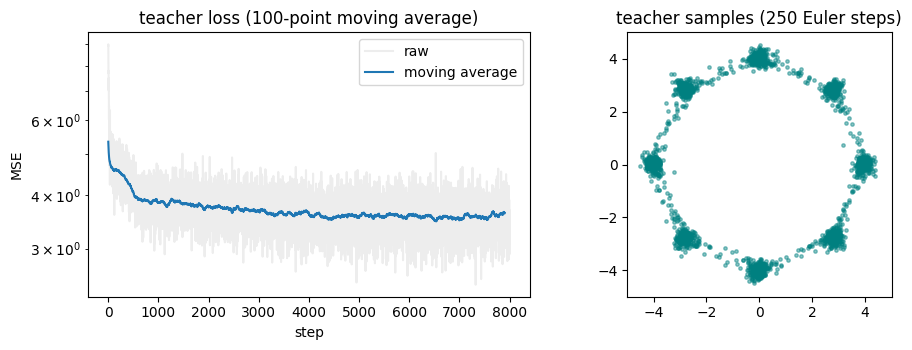

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(teacher_losses, color="0.8", alpha=0.35, label="raw")

def moving_average(values, window=100):
    values = np.asarray(values)
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


axes[0].plot(moving_average(teacher_losses, window=100), color="C0", label="moving average")
axes[0].set_title("teacher loss (100-point moving average)")
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")
axes[0].legend()

# Shared evaluation batches used by all metric tables below.
EVAL_NOISE = sample_source(5000)
TRUE_RING_EVAL = sample_ring(5000)
SLICED_W_SEED = 77
teacher_samples_250 = euler_sample_velocity(v_teacher, EVAL_NOISE, n_steps=250)

plot_samples(teacher_samples_250[:3000], axes[1], title="teacher samples (250 Euler steps)", color="teal")
plt.tight_layout()
plt.show()

We will use **Sliced Wasserstein distance** as the main distribution metric.
For two point clouds, it works like this:

1. project both clouds onto many random 1D lines,
2. sort the projected points on each line,
3. compare the sorted values,
4. average over all projection directions.

Lower is better. Unlike mode counts, Sliced Wasserstein notices geometry: if a
ring mode is shifted inward or outward, the distance increases. To avoid noisy
table-to-table changes, every table below uses the same fixed evaluation noise
batch and the same fixed true-ring reference batch.

In [6]:
display_markdown_table(
    ["Check", "Value"],
    [
        ["Sliced W: teacher vs true ring", f"{sliced_wasserstein(teacher_samples_250, TRUE_RING_EVAL, seed=SLICED_W_SEED):.4f}"],
    ],
)

| Check | Value |
| --- | --- |
| Sliced W: teacher vs true ring | 0.2533 |

The velocity model works, but it is still a **local** model. To move from noise
to data, we keep asking:

> "At this exact time and location, which direction should I move next?"

If we take too few Euler steps, each step becomes too large and the trajectory
can drift away from the teacher's intended path.

In [7]:
teacher_eval_rows = []
for nfe in [250, 8, 4, 2]:
    samples = euler_sample_velocity(v_teacher, EVAL_NOISE, n_steps=nfe)
    sw_ring = sliced_wasserstein(samples, TRUE_RING_EVAL, seed=SLICED_W_SEED)
    teacher_eval_rows.append([
        f"Euler velocity ({nfe} NFE)",
        nfe,
        f"{sw_ring:.4f}",
    ])

display_markdown_table(
    [
        "Sampler",
        "NFE",
        "Sliced W vs true ring",
    ],
    teacher_eval_rows,
)

| Sampler | NFE | Sliced W vs true ring |
| --- | --- | --- |
| Euler velocity (250 NFE) | 250 | 0.2533 |
| Euler velocity (8 NFE) | 8 | 0.3226 |
| Euler velocity (4 NFE) | 4 | 0.3256 |
| Euler velocity (2 NFE) | 2 | 0.9366 |

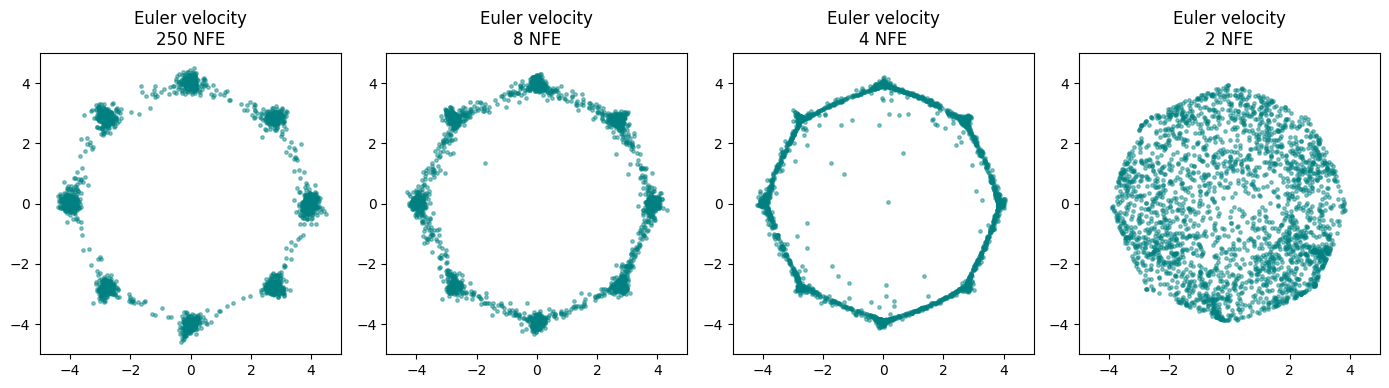

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, nfe in zip(axes, [250, 8, 4, 2]):
    samples = euler_sample_velocity(v_teacher, sample_source(2500), n_steps=nfe)
    plot_samples(samples, ax, title=f"Euler velocity\n{nfe} NFE", color="teal")
plt.tight_layout()
plt.show()

## 2. A flow map predicts the integral, not the tangent

A velocity field tells us the local tangent direction. A flow map tries to jump
directly between two times on the same path:

$$
F_\phi(x_s,s,t) \approx x_t.
$$

Here:

* $x_s$ is a point on a teacher trajectory at source time $s$,
* $t$ is the target time,
* $F_\phi(x_s,s,t)$ should land at the point $x_t$ on the same trajectory.

The most convenient parameterization is the **average velocity**:

$$
F_\phi(x_s,s,t)
=
x_s + (t-s)V_\phi(x_s,s,t).
$$

This mirrors the exact identity:

$$
x_t
=
x_s + \int_s^t v(x_\tau,\tau)\,d\tau.
$$

So $V_\phi$ is trying to learn the average velocity over the whole interval
from $s$ to $t$. If it is accurate, we can replace many tiny Euler steps with
one large jump.

In [9]:
class FlowMapNet(nn.Module):
    def __init__(self, hidden: int = 192, n_freqs: int = 8):
        super().__init__()
        self.time_emb = TimeEmbedding(n_freqs)
        in_dim = 2 + 4 * n_freqs
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 2),
        )

    def average_velocity(self, x: torch.Tensor, s: torch.Tensor, t: torch.Tensor):
        return self.net(torch.cat([x, self.time_emb(s), self.time_emb(t)], dim=-1))

    def forward(self, x: torch.Tensor, s: torch.Tensor, t: torch.Tensor):
        return x + (t - s)[:, None] * self.average_velocity(x, s, t)


@torch.no_grad()
def sample_flow_map(model: FlowMapNet, start: torch.Tensor, *, n_steps: int):
    x = start.clone()
    n = x.shape[0]
    times = torch.linspace(1.0, 0.0, n_steps + 1)
    for k in range(n_steps):
        s = torch.full((n,), times[k].item())
        t = torch.full((n,), times[k + 1].item())
        x = model(x, s, t)
    return x


display_markdown_table(
    ["Quantity", "Value"],
    [["Flow-map parameters", f"{num_params(FlowMapNet()):,}"]],
)

| Quantity | Value |
| --- | --- |
| Flow-map parameters | 44,162 |

## 3. The three consistency ideas

All three consistency ideas say the same thing from different angles:

> A valid flow map should move along one coherent path.

### 1. Semigroup / compositional consistency

Going from $s$ to $t$ directly should match going from $s$ to an intermediate
time $m$, then from $m$ to $t$:

$$
F(F(x_s,s,m),m,t) = F(x_s,s,t),
\qquad t < m < s.
$$

This is also called the **semigroup** property. It is the most intuitive rule
and does not require derivatives. Our practical version treats the two-step path
as a stop-gradient target:

$$
\mathcal{L}_{\text{semigroup}}
=
\left\|
F_\phi(x_s,s,t)
-
\operatorname{sg}\!\left[
F_\phi(F_\phi(x_s,s,m),m,t)
\right]
\right\|^2.
$$

### 2. Lagrangian consistency via LMD

If we keep the source fixed and move the target time a little, the output should
move with the velocity at the target:

$$
\frac{\partial}{\partial t}F(x_s,s,t)
=
v(F(x_s,s,t),t).
$$

This follows a particle along the path, like sitting in a canoe.

We enforce this idea with **Lagrangian Map Distillation (LMD)**. Pick an
intermediate time $m$ between $s$ and $t$:

$$
t < m < s.
$$

First ask the current flow map to jump from $s$ to $m$:

$$
\tilde x_m = F_\phi(x_s,s,m).
$$

Then use one local teacher-velocity step to move from $m$ to $t$:

$$
\tilde x_t
=
\tilde x_m
+
(t-m)\,v_{\text{teacher}}(\tilde x_m,m).
$$

The LMD training loss is:

$$
\mathcal{L}_{\text{LMD}}
=
\left\|
F_\phi(x_s,s,t)
-
\operatorname{sg}[\tilde x_t]
\right\|^2.
$$

So LMD does **not** need a stored teacher endpoint $x_t$. It creates a target
from the current map plus one local teacher velocity evaluation.

### 3. Eulerian consistency via EMD

If we move the source point along the path while keeping the target time fixed,
the final destination should not change:

$$
\frac{\partial}{\partial s}F(x_s,s,t)
+
\nabla_{x_s}F(x_s,s,t)\,v(x_s,s)
=
0.
$$

This watches the flow from a fixed target, like standing on a bridge.

We enforce this idea with **Eulerian Map Distillation (EMD)**. Again pick an
intermediate time $m$ between $s$ and $t$:

$$
t < m < s.
$$

Move the source point from $s$ to $m$ using one teacher velocity step:

$$
\tilde x_m
=
x_s
+
(m-s)\,v_{\text{teacher}}(x_s,s).
$$

If the final target time is still $t$, the destination should be the same:

$$
F(x_s,s,t)
\approx
F(\tilde x_m,m,t).
$$

The EMD training loss is:

$$
\mathcal{L}_{\text{EMD}}
=
\left\|
F_\phi(x_s,s,t)
-
\operatorname{sg}\!\left[
F_\phi(\tilde x_m,m,t)
\right]
\right\|^2.
$$

So EMD also avoids stored full teacher trajectories. It creates a target by
moving the source locally and then reusing the map.

## 4. Route A: pretrained teacher $\rightarrow$ flow map

Route A assumes we already have a trained velocity model $v_{\text{teacher}}$.
This is common in practice: start from a high-quality diffusion/flow model and
distill it into a few-step flow map.

The most literal mental model would be to store full teacher trajectories and
train

$$
F_\phi(x_s,s,t)\approx x_t^{\text{teacher}}.
$$

This is easy to understand, but expensive and not scalable. Instead, we train
with local teacher velocity evaluations and EMA stop-gradient targets:

* **Semigroup-style:** two jumps should match one jump.
* **LMD-style:** predict an intermediate endpoint, then take one local teacher
  step toward the target.
* **EMD-style:** move the source by one local teacher step, then preserve the
  final target.

For training, we borrow the **diagonal/off-diagonal batch split** pattern from
Boffi et al.'s official
[`flow-maps`](https://github.com/nmboffi/flow-maps) implementation
(`py/common/loss_args.py` and `py/common/losses.py`): each optimization step
mixes a small diagonal velocity batch with an off-diagonal consistency batch.
This keeps the local velocity grounded while the model learns long jumps.

In [10]:
def update_ema_model(ema_model: FlowMapNet, model: FlowMapNet, decay: float = 0.995):
    with torch.no_grad():
        for ema_param, param in zip(ema_model.parameters(), model.parameters()):
            ema_param.mul_(decay).add_(param, alpha=1 - decay)


def make_ema_model(model: FlowMapNet) -> FlowMapNet:
    ema_model = FlowMapNet()
    ema_model.load_state_dict(model.state_dict())
    ema_model.eval()
    for p in ema_model.parameters():
        p.requires_grad_(False)
    return ema_model


def sample_data_interpolant_batch(batch_size: int = 512):
    x0 = sample_ring(batch_size)
    eps = sample_source(batch_size)
    s = 0.05 + 0.95 * torch.rand(batch_size)
    t = s * torch.rand(batch_size)
    mix = 0.2 + 0.6 * torch.rand(batch_size)
    m = t + mix * (s - t)
    x_s = (1 - s[:, None]) * x0 + s[:, None] * eps
    return x0, eps, x_s, s, m, t


def diagonal_teacher_loss(model: FlowMapNet, batch_size: int = 512):
    _, _, x_s, s, _, _ = sample_data_interpolant_batch(batch_size)
    with torch.no_grad():
        target_velocity = v_teacher(x_s, s)
    return ((model.average_velocity(x_s, s, s) - target_velocity) ** 2).mean()


def route_a_semigroup_loss(model: FlowMapNet, target_model: FlowMapNet, batch_size: int = 512):
    _, _, x_s, s, m, t = sample_data_interpolant_batch(batch_size)
    with torch.no_grad():
        target = target_model(target_model(x_s, s, m), m, t)
    return ((model(x_s, s, t) - target) ** 2).mean()


def route_a_lmd_loss(model: FlowMapNet, target_model: FlowMapNet, batch_size: int = 512):
    _, _, x_s, s, m, t = sample_data_interpolant_batch(batch_size)
    with torch.no_grad():
        x_m = target_model(x_s, s, m)
        target = x_m + (t - m)[:, None] * v_teacher(x_m, m)
    return ((model(x_s, s, t) - target) ** 2).mean()


def route_a_emd_loss(model: FlowMapNet, target_model: FlowMapNet, batch_size: int = 512):
    _, _, x_s, s, m, t = sample_data_interpolant_batch(batch_size)
    with torch.no_grad():
        x_m = x_s + (m - s)[:, None] * v_teacher(x_s, s)
        target = target_model(x_m, m, t)
    return ((model(x_s, s, t) - target) ** 2).mean()


def train_route_a(
    kind: str,
    *,
    steps: int = 6000,
    batch_size: int = 512,
    diag_fraction: float = 0.3,
):
    model = FlowMapNet()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    target_model = make_ema_model(model)

    diag_bs = max(1, int(batch_size * diag_fraction))
    offdiag_bs = batch_size - diag_bs

    for _ in tqdm(range(steps), desc=f"Route A {kind}", disable=not SHOW_PROGRESS, leave=False):
        loss = diag_fraction * diagonal_teacher_loss(model, batch_size=diag_bs)

        if kind == "semigroup":
            consistency = route_a_semigroup_loss(model, target_model, batch_size=offdiag_bs)
        elif kind == "lmd":
            consistency = route_a_lmd_loss(model, target_model, batch_size=offdiag_bs)
        elif kind == "emd":
            consistency = route_a_emd_loss(model, target_model, batch_size=offdiag_bs)
        else:
            raise ValueError(kind)

        loss = loss + (1 - diag_fraction) * consistency
        opt.zero_grad()
        loss.backward()
        opt.step()
        update_ema_model(target_model, model)

    model.eval()
    return model


METHOD_SEED = 41


torch.manual_seed(METHOD_SEED)
route_a_semigroup = train_route_a("semigroup")
torch.manual_seed(METHOD_SEED)
route_a_lmd = train_route_a("lmd")
torch.manual_seed(METHOD_SEED)
route_a_emd = train_route_a("emd")

display_markdown_table(
    ["Route A method", "Uses full teacher trajectories?", "Training signal"],
    [
        ["Semigroup", "no", "EMA target: two jumps match one jump"],
        ["LMD", "no", "EMA target + one local teacher step at predicted endpoint"],
        ["EMD", "no", "teacher-moved source + EMA target map"],
    ],
)

| Route A method | Uses full teacher trajectories? | Training signal |
| --- | --- | --- |
| Semigroup | no | EMA target: two jumps match one jump |
| LMD | no | EMA target + one local teacher step at predicted endpoint |
| EMD | no | teacher-moved source + EMA target map |

## 5. Route B: direct/self-distilled flow map

Route B does not assume a separate pretrained velocity teacher. It trains the
flow map and its diagonal velocity together from data.

Because Route B bootstraps from its own predictions, it is more sensitive to
under-training than Route A. We therefore train these variants for more
optimization steps in the toy experiment.

The diagonal loss is ordinary flow matching:

$$
V_\phi(X_s,s,s)\approx \varepsilon-X_0.
$$

For off-diagonal jumps, we implement simplified versions of the three
self-distillation objectives from Boffi et al.'s [`flow-maps` implementation](https://github.com/nmboffi/flow-maps):

* **PSD**: progressive / semigroup self-distillation.
* **LSD**: Lagrangian self-distillation. It asks: if we move the **target time**
  $t$ a little, does the flow-map output move with the velocity at that output?
* **ESD**: Eulerian self-distillation. It asks: if we move the **source state**
  along the path a little, does the final destination stay the same?

Both LSD and ESD need a **directional derivative**, also called a
**Jacobian-vector product (JVP)**.

A simple way to read a JVP is:

$$
\operatorname{JVP}[f](x;\delta)
\approx
\frac{f(x+\epsilon\delta)-f(x)}{\epsilon}.
$$

It tells us how the output of $f$ changes if we nudge the input $x$ in the
direction $\delta$. The important part is that we never build the full Jacobian
matrix. `torch.func.jvp` gives the directional derivative directly.

For **LSD**, the function is:

$$
f(t)=F_\phi(x_s,s,t).
$$

We nudge the target time in direction $1$, so the JVP gives:

$$
\partial_t F_\phi(x_s,s,t).
$$

For **ESD**, the function is:

$$
f(x_s,s)=F_\phi(x_s,s,t).
$$

We nudge $(x_s,s)$ in the direction $(v(x_s,s),1)$, so the JVP gives:

$$
\nabla_{x_s}F_\phi(x_s,s,t)\,v(x_s,s)
+
\partial_s F_\phi(x_s,s,t).
$$

That is exactly the Eulerian residual.

Following the official `flow-maps` training structure, every optimization step
uses a **diagonal/off-diagonal batch split**: part of the batch trains the
diagonal velocity, and the rest trains the off-diagonal consistency objective.

In [11]:
def diagonal_data_loss(model: FlowMapNet, batch_size: int = 256):
    x0, eps, x_s, s, _, _ = sample_data_interpolant_batch(batch_size)
    target_velocity = eps - x0
    return ((model.average_velocity(x_s, s, s) - target_velocity) ** 2).mean()


def route_b_psd_loss(model: FlowMapNet, target_model: FlowMapNet, batch_size: int = 256):
    _, _, x_s, s, m, t = sample_data_interpolant_batch(batch_size)
    with torch.no_grad():
        target = target_model(target_model(x_s, s, m), m, t)
    return ((model(x_s, s, t) - target) ** 2).mean()


def route_b_lsd_loss(model: FlowMapNet, target_model: FlowMapNet, batch_size: int = 128):
    _, _, x_s, s, _, t = sample_data_interpolant_batch(batch_size)

    # Lagrangian view:
    # f(t) = F(x_s, s, t). Nudging t in direction 1 gives dF/dt.
    def flow_as_function_of_t(t_in):
        return model(x_s, s, t_in)

    x_t_pred, dF_dt = torch.func.jvp(
        flow_as_function_of_t,
        (t,),
        (torch.ones_like(t),),
    )

    with torch.no_grad():
        # On the diagonal, average velocity V(x, t, t) acts like the local velocity.
        target_velocity = target_model.average_velocity(x_t_pred.detach(), t, t)
    return ((dF_dt - target_velocity) ** 2).mean()


def route_b_esd_loss(model: FlowMapNet, target_model: FlowMapNet, batch_size: int = 128):
    _, _, x_s, s, _, t = sample_data_interpolant_batch(batch_size)
    with torch.no_grad():
        source_velocity = target_model.average_velocity(x_s, s, s)

    # Eulerian view:
    # f(x_s, s) = F(x_s, s, t). Nudging (x_s, s) by (v, 1) gives
    # ∇_x F · v + ∂_s F, which should be zero for a consistent map.
    def flow_as_function_of_source(x_in, s_in):
        return model(x_in, s_in, t)

    _, directional_derivative = torch.func.jvp(
        flow_as_function_of_source,
        (x_s, s),
        (source_velocity, torch.ones_like(s)),
    )
    return (directional_derivative ** 2).mean()


def train_route_b(
    kind: str,
    *,
    steps: int = 6000,
    batch_size: int = 512,
    diag_fraction: float = 0.3,
):
    model = FlowMapNet()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    target_model = make_ema_model(model)

    diag_bs = max(1, int(batch_size * diag_fraction))
    offdiag_bs = batch_size - diag_bs

    for _ in tqdm(range(steps), desc=f"Route B {kind}", disable=not SHOW_PROGRESS, leave=False):
        loss = diag_fraction * diagonal_data_loss(model, batch_size=diag_bs)

        if kind == "psd":
            consistency = route_b_psd_loss(model, target_model, batch_size=offdiag_bs)
        elif kind == "lsd":
            consistency = 0.02 * route_b_lsd_loss(model, target_model, batch_size=max(64, offdiag_bs // 4))
        elif kind == "esd":
            consistency = 0.1 * route_b_esd_loss(model, target_model, batch_size=max(64, offdiag_bs // 4))
        else:
            raise ValueError(kind)

        loss = loss + (1 - diag_fraction) * consistency
        opt.zero_grad()
        loss.backward()
        opt.step()
        update_ema_model(target_model, model)

    model.eval()
    return model


torch.manual_seed(METHOD_SEED)
route_b_psd = train_route_b("psd")
torch.manual_seed(METHOD_SEED)
route_b_lsd = train_route_b("lsd")
torch.manual_seed(METHOD_SEED)
route_b_esd = train_route_b("esd")

display_markdown_table(
    ["Route B method", "Separate teacher?", "Key mechanism"],
    [
        ["PSD", "no", "semigroup / progressive self-distillation"],
        ["LSD", "no", "Lagrangian JVP: $\\partial_t F$"],
        ["ESD", "no", "Eulerian JVP: $\\partial_s F + \\nabla_xFv$"],
    ],
)

| Route B method | Separate teacher? | Key mechanism |
| --- | --- | --- |
| PSD | no | semigroup / progressive self-distillation |
| LSD | no | Lagrangian JVP: $\partial_t F$ |
| ESD | no | Eulerian JVP: $\partial_s F + \nabla_xFv$ |

## 6. Comparison

Now we compare:

* the original velocity model with coarse Euler steps,
* Route A teacher-based flow maps,
* Route B self-distilled flow maps.

We report sample quality against the true ring with Sliced Wasserstein, across
1, 2, 4, and 8 NFEs. Lower is better; the winner for each NFE column is bolded.

All Route A/B methods use the same training seed (`41`) for this toy
comparison. This keeps the table fair, but it is still a single-seed result, so
small differences should not be over-interpreted.

In [12]:
comparison_noise = EVAL_NOISE
comparison_ring = TRUE_RING_EVAL
nfe_values = [1, 2, 4, 8]

method_specs = [
    ("Coarse Euler", lambda nfe: euler_sample_velocity(v_teacher, comparison_noise, n_steps=nfe), "C3"),
    ("Route A: Semigroup", lambda nfe: sample_flow_map(route_a_semigroup, comparison_noise, n_steps=nfe), "C1"),
    ("Route A: LMD", lambda nfe: sample_flow_map(route_a_lmd, comparison_noise, n_steps=nfe), "C5"),
    ("Route A: EMD", lambda nfe: sample_flow_map(route_a_emd, comparison_noise, n_steps=nfe), "C6"),
    ("Route B: PSD", lambda nfe: sample_flow_map(route_b_psd, comparison_noise, n_steps=nfe), "C0"),
    ("Route B: LSD", lambda nfe: sample_flow_map(route_b_lsd, comparison_noise, n_steps=nfe), "C2"),
    ("Route B: ESD", lambda nfe: sample_flow_map(route_b_esd, comparison_noise, n_steps=nfe), "C4"),
]

comparison_metrics = []
for method_name, sampler, color in method_specs:
    for nfe in nfe_values:
        samples = sampler(nfe)
        sw = sliced_wasserstein(samples, comparison_ring, seed=SLICED_W_SEED)
        comparison_metrics.append({
            "method": method_name,
            "nfe": nfe,
            "sw": sw,
            "color": color,
        })

best_sw_by_nfe = {
    nfe: min(row["sw"] for row in comparison_metrics if row["nfe"] == nfe)
    for nfe in nfe_values
}

comparison_rows = []
for method_name, _, _ in method_specs:
    row = [method_name]
    for nfe in nfe_values:
        metric = next(r for r in comparison_metrics if r["method"] == method_name and r["nfe"] == nfe)
        sw_text = f"{metric['sw']:.4f}"
        if abs(metric["sw"] - best_sw_by_nfe[nfe]) < 1e-8:
            sw_text = f"**{sw_text}**"
        row.append(sw_text)
    comparison_rows.append(row)

display_markdown_table(
    ["Method"] + [f"{nfe} NFE" for nfe in nfe_values],
    comparison_rows,
)

| Method | 1 NFE | 2 NFE | 4 NFE | 8 NFE |
| --- | --- | --- | --- | --- |
| Coarse Euler | 2.7306 | 0.9366 | 0.3256 | 0.3226 |
| Route A: Semigroup | **0.2838** | **0.2390** | **0.2371** | **0.2571** |
| Route A: LMD | 0.5596 | 0.3746 | 0.3312 | 0.3391 |
| Route A: EMD | 0.9457 | 0.3703 | 0.2554 | 0.2576 |
| Route B: PSD | 0.4244 | 0.2938 | 0.3231 | 0.3110 |
| Route B: LSD | 0.3695 | 0.3060 | 0.3651 | 0.3800 |
| Route B: ESD | 0.4797 | 0.3304 | 0.3487 | 0.3581 |

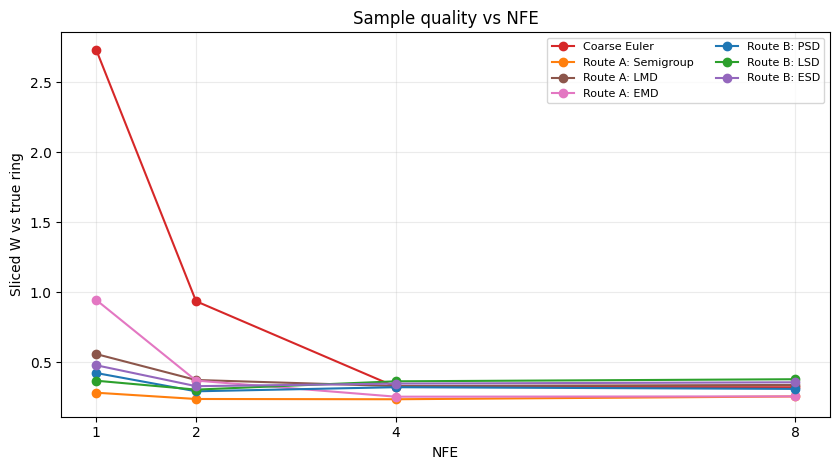

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for method_name, _, color in method_specs:
    rows = [r for r in comparison_metrics if r["method"] == method_name]
    rows = sorted(rows, key=lambda r: r["nfe"])
    ax.plot(
        [r["nfe"] for r in rows],
        [r["sw"] for r in rows],
        marker="o",
        label=method_name,
        color=color,
    )

ax.set_title("Sample quality vs NFE")
ax.set_xlabel("NFE")
ax.set_ylabel("Sliced W vs true ring")
ax.set_xticks(nfe_values)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

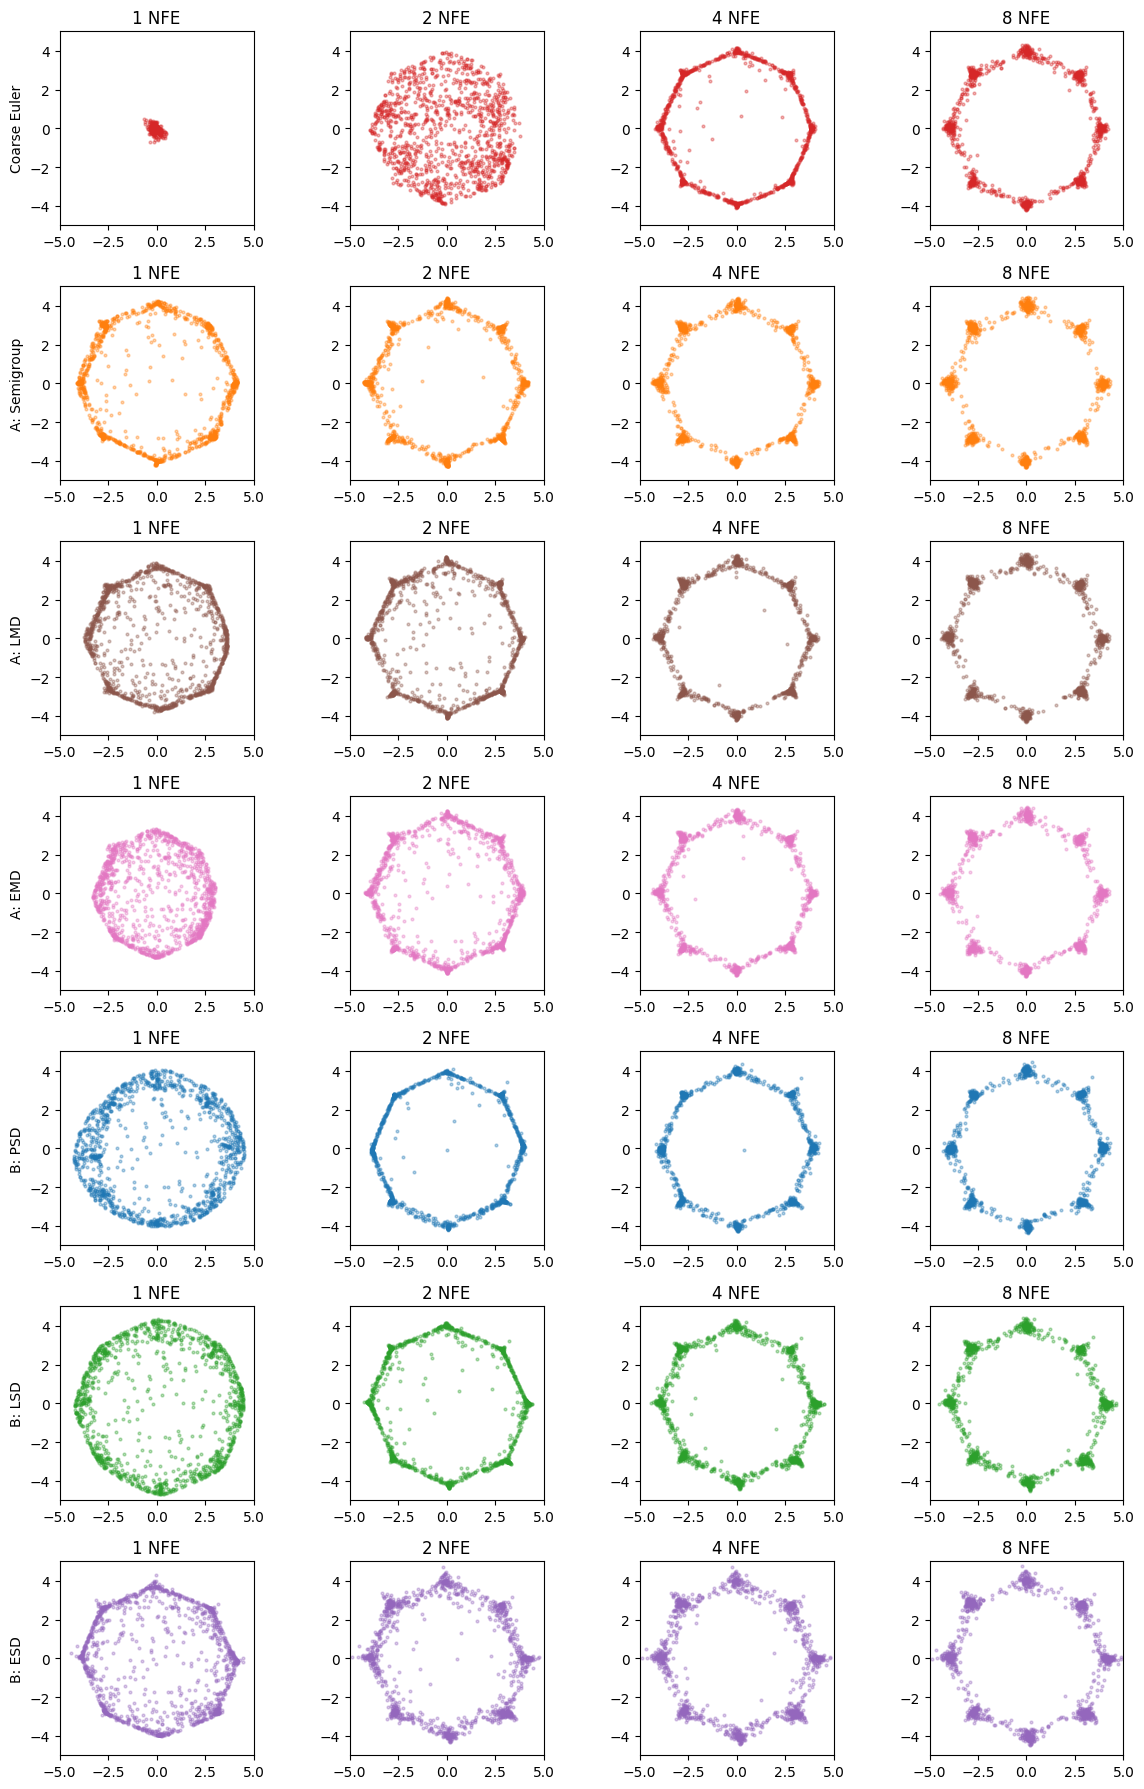

In [14]:
plot_noise = sample_source(1200)
grid_method_specs = [
    ("Coarse Euler", lambda nfe: euler_sample_velocity(v_teacher, plot_noise, n_steps=nfe), "C3"),
    ("A: Semigroup", lambda nfe: sample_flow_map(route_a_semigroup, plot_noise, n_steps=nfe), "C1"),
    ("A: LMD", lambda nfe: sample_flow_map(route_a_lmd, plot_noise, n_steps=nfe), "C5"),
    ("A: EMD", lambda nfe: sample_flow_map(route_a_emd, plot_noise, n_steps=nfe), "C6"),
    ("B: PSD", lambda nfe: sample_flow_map(route_b_psd, plot_noise, n_steps=nfe), "C0"),
    ("B: LSD", lambda nfe: sample_flow_map(route_b_lsd, plot_noise, n_steps=nfe), "C2"),
    ("B: ESD", lambda nfe: sample_flow_map(route_b_esd, plot_noise, n_steps=nfe), "C4"),
]

fig, axes = plt.subplots(len(grid_method_specs), len(nfe_values), figsize=(12, 18))
for row, (method_name, sampler, color) in enumerate(grid_method_specs):
    for col, nfe in enumerate(nfe_values):
        samples = sampler(nfe)
        title = f"{nfe} NFE" if row > 0 else f"{nfe} NFE"
        plot_samples(samples, axes[row, col], title=title, color=color, s=4, alpha=0.35)
        if col == 0:
            axes[row, col].set_ylabel(method_name, fontsize=10)

plt.tight_layout()
plt.show()

**Findings:**

* Coarse Euler collapses at very low NFE because it is still trying to integrate
  a local velocity field with huge steps.
* Route A uses a pretrained teacher and is closest to practical teacher
  distillation.
* Route B is closer to the official `flow-maps` self-distillation style: it
  learns the diagonal velocity and off-diagonal jumps together.
* Route A and Route B are trained with the same optimization budget in this
  comparison. Route A benefits from a pretrained teacher velocity; Route B has
  to learn the diagonal velocity and off-diagonal jumps together.
* In this single-seed toy run, **Route A semigroup** wins at all reported NFE
  budgets. This makes sense: it gets help from a pretrained teacher velocity,
  while still using a simple stable semigroup target.
* Route B methods are more ambitious: they learn the velocity and the flow map
  together from data. They are closer to the official `flow-maps`
  self-distillation setting, but need more careful tuning to beat the
  teacher-distillation route in this small example.
* Semigroup/PSD-style losses are the simplest and most stable derivative-free
  objectives in this toy.
* LSD/ESD expose why JVP matters in real implementations: they directly train
  derivatives of the learned operator.

## 7. Extension: one-stage reward-tilted flow maps

The previous sections were about **step distillation**: how to sample faster.
Flow maps can also be combined with **reward tilting**, using the same idea we
studied in the [ITM tutorial](https://xing-mei.github.io/notes/tilt_matching_tutorial/).

The reward-tilted target has the familiar form:

$$
p_{\text{target}}(x)
\propto
p_{\text{ref}}(x)\,e^{\beta r(x)}.
$$

For a velocity model, ITM uses the full exponential coefficient
$e^{\beta r}-1$. For a flow map, the Tilt Matching paper's flow-map remark says
to apply ITM on the **diagonal velocity** $V_\phi(x_s,s,s)$ while also enforcing
flow-map consistency. That gives a one-stage recipe:

1. use ITM to learn the reward-tilted local velocity,
2. use semigroup consistency to make the model a few-step flow map.

The ITM diagonal target is:

$$
T^{\text{ITM-diag}}
=
v_{\text{teacher}}(X_s,s)
+
\left(e^{\beta r(X_0)}-1\right)
\left[
(\varepsilon-X_0)
-
\operatorname{sg}(V_\phi(X_s,s,s))
\right].
$$

We do **not** first distill a base flow map and then reward-tune it. Instead,
we start from the pretrained velocity teacher and train a new flow map with both
losses in the same loop:

$$
\mathcal{L}
=
\mathcal{L}_{\text{ITM-diag}}
+
\lambda\,\mathcal{L}_{\text{semigroup}}.
$$

What does the Tilt Matching paper claim this buys us? The paper does **not**
directly compare against a two-stage "distill a flow map, then RL-tune it"
pipeline. Its point is more structural:

* ITM learns the reward-tilted velocity correction **directly**, rather than
  taking many small annealing steps.
* The ITM objective avoids reward gradients and backpropagation through sampler
  trajectories.
* For flow maps, the paper notes that one can enforce the ITM condition on the
  diagonal velocity $V_\phi(x,t,t)$ while also enforcing flow-map consistency.

So the benefit we illustrate here is not "proven better than two-stage." It is:
the reward tilt and the few-step flow-map structure can be trained as one
coherent objective.

This is a toy extension, not a reproduction of Tilt Matching's large-scale
experiments. The goal is to show that flow-map distillation and reward tilting
can live in the same training loop.

In [15]:
def reward(x: torch.Tensor, center=(4.0, 0.0), scale: float = 2.5):
    c = torch.as_tensor(center, dtype=x.dtype, device=x.device)
    return torch.exp(-0.5 * ((x - c) ** 2).sum(-1) / scale**2)


TILT_BETA = 4.0


@torch.no_grad()
def make_velocity_reference_endpoint_pool(ref_velocity: VelocityNet, n: int = 8000, n_steps: int = 250):
    return euler_sample_velocity(ref_velocity, sample_source(n), n_steps=n_steps)


@torch.no_grad()
def sample_target_from_reference_pool(pool: torch.Tensor, n: int, beta: float = TILT_BETA, seed: int = 0):
    weights = torch.exp(beta * reward(pool))
    probs = weights / weights.sum()
    gen = torch.Generator().manual_seed(seed)
    idx = torch.multinomial(probs, n, replacement=True, generator=gen)
    return pool[idx]


def sample_ref_interpolant_batch(endpoint_pool: torch.Tensor, batch_size: int = 512):
    idx = torch.randint(len(endpoint_pool), (batch_size,))
    x0 = endpoint_pool[idx]
    eps = sample_source(batch_size)
    s = 0.05 + 0.95 * torch.rand(batch_size)
    t = s * torch.rand(batch_size)
    mix = 0.2 + 0.6 * torch.rand(batch_size)
    m = t + mix * (s - t)
    x_s = (1 - s[:, None]) * x0 + s[:, None] * eps
    xdot = eps - x0
    return x0, eps, x_s, xdot, s, m, t


def itm_diagonal_loss(model: FlowMapNet, ref_velocity: VelocityNet, endpoint_pool: torch.Tensor, batch_size: int = 512):
    x0, eps, x_s, xdot, s, _, _ = sample_ref_interpolant_batch(endpoint_pool, batch_size)
    pred = model.average_velocity(x_s, s, s)
    with torch.no_grad():
        v_ref = ref_velocity(x_s, s)
        v_sg = model.average_velocity(x_s, s, s)
        coeff = torch.expm1(TILT_BETA * reward(x0))
        target = v_ref + coeff[:, None] * (xdot - v_sg)
    return ((pred - target) ** 2).mean()


def semigroup_loss_on_ref_pool(model: FlowMapNet, target_model: FlowMapNet, endpoint_pool: torch.Tensor, batch_size: int = 512):
    _, _, x_s, _, s, m, t = sample_ref_interpolant_batch(endpoint_pool, batch_size)
    with torch.no_grad():
        target = target_model(target_model(x_s, s, m), m, t)
    pred = model(x_s, s, t)
    return ((pred - target) ** 2).mean()


def train_reward_tilted_flow_map(ref_velocity: VelocityNet, steps: int = 5000, batch_size: int = 512):
    model = FlowMapNet()
    target_model = make_ema_model(model)
    for p in ref_velocity.parameters():
        p.requires_grad_(False)

    endpoint_pool = make_velocity_reference_endpoint_pool(ref_velocity)
    opt = torch.optim.Adam(model.parameters(), lr=5e-4)
    losses = []
    pbar = tqdm(range(steps), desc="reward-tilted flow map", disable=not SHOW_PROGRESS, leave=False)
    for _ in pbar:
        loss_itm = itm_diagonal_loss(model, ref_velocity, endpoint_pool, batch_size)
        loss_semigroup = semigroup_loss_on_ref_pool(model, target_model, endpoint_pool, batch_size)
        loss = 0.5 * loss_itm + 0.5 * loss_semigroup
        opt.zero_grad()
        loss.backward()
        opt.step()
        update_ema_model(target_model, model)
        losses.append(loss.item())
    model.eval()
    return model, losses, endpoint_pool


torch.manual_seed(314)
tilted_flow_map, tilted_losses, reference_endpoint_pool = train_reward_tilted_flow_map(v_teacher)

target_tilt_samples = sample_target_from_reference_pool(reference_endpoint_pool, 5000, seed=2026)
base_samples = euler_sample_velocity(v_teacher, EVAL_NOISE, n_steps=250)
tilted_samples_by_nfe = {
    nfe: sample_flow_map(tilted_flow_map, EVAL_NOISE, n_steps=nfe)
    for nfe in [1, 2, 4, 8]
}


def evaluate_reward_sampler(name: str, samples: torch.Tensor):
    return {
        "name": name,
        "mean_reward": reward(samples).mean().item(),
        "sliced_w_target": sliced_wasserstein(samples, target_tilt_samples, seed=SLICED_W_SEED),
    }


reward_evals = [
    {"name": "base velocity teacher", "nfe": "250", **evaluate_reward_sampler("base velocity teacher", base_samples)},
    {"name": "analytic tilted target", "nfe": "-", **evaluate_reward_sampler("analytic tilted target", target_tilt_samples)},
]

flow_map_reward_evals = []
for nfe, samples in tilted_samples_by_nfe.items():
    flow_map_reward_evals.append({
        "name": "one-stage ITM + semigroup flow map",
        "nfe": str(nfe),
        **evaluate_reward_sampler("one-stage ITM + semigroup flow map", samples),
    })
best_flow_map_sw = min(e["sliced_w_target"] for e in flow_map_reward_evals)
reward_evals.extend(flow_map_reward_evals)

display_markdown_table(
    ["Sampler", "NFE", "Mean reward ↑", "Sliced W to tilted target ↓"],
    [
        [
            e["name"],
            e["nfe"],
            f"{e['mean_reward']:.3f}",
            (
                f"**{e['sliced_w_target']:.4f}**"
                if e["name"].startswith("one-stage") and abs(e["sliced_w_target"] - best_flow_map_sw) < 1e-8
                else f"{e['sliced_w_target']:.4f}"
            ),
        ]
        for e in reward_evals
    ],
)

| Sampler | NFE | Mean reward ↑ | Sliced W to tilted target ↓ |
| --- | --- | --- | --- |
| base velocity teacher | 250 | 0.274 | 3.0995 |
| analytic tilted target | - | 0.829 | 0.0000 |
| one-stage ITM + semigroup flow map | 1 | 0.719 | 0.8203 |
| one-stage ITM + semigroup flow map | 2 | 0.700 | 0.9119 |
| one-stage ITM + semigroup flow map | 4 | 0.783 | 0.4831 |
| one-stage ITM + semigroup flow map | 8 | 0.815 | **0.2662** |

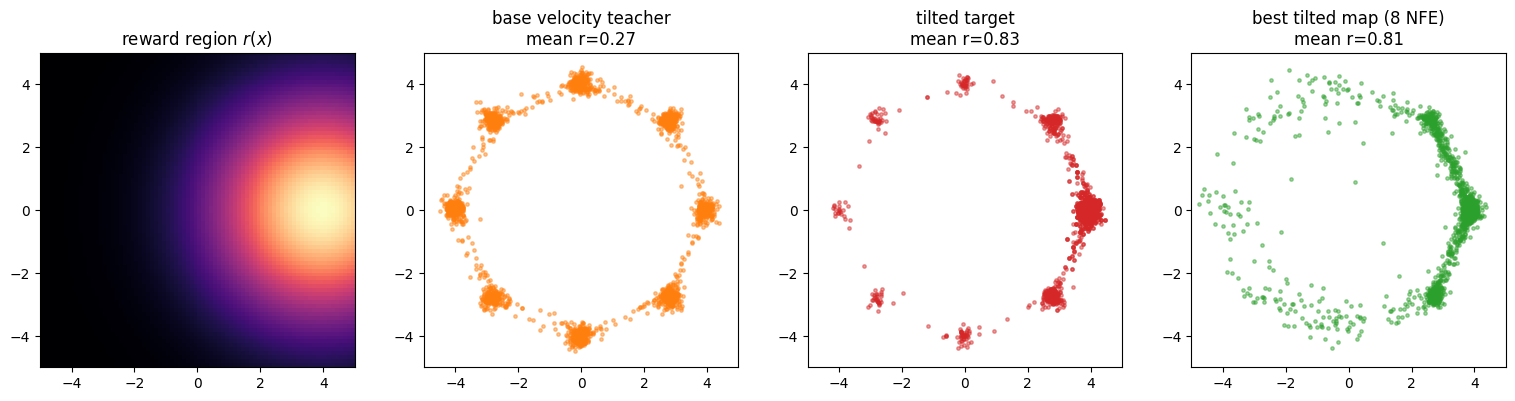

In [16]:
def plot_reward_heatmap(ax, n_grid: int = 80):
    grid, _, _ = make_grid(n_grid=n_grid)
    z = reward(grid).reshape(n_grid, n_grid)
    ax.imshow(z.T.cpu().numpy(), origin="lower", extent=(-5, 5, -5, 5), cmap="magma")
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect("equal")
    ax.set_title("reward region $r(x)$")
    return ax


best_nfe = min(
    tilted_samples_by_nfe,
    key=lambda nfe: sliced_wasserstein(tilted_samples_by_nfe[nfe], target_tilt_samples, seed=SLICED_W_SEED),
)
best_tilted_samples = tilted_samples_by_nfe[best_nfe]
best_eval = next(e for e in flow_map_reward_evals if e["nfe"] == str(best_nfe))

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.8))
plot_reward_heatmap(axes[0])
plot_samples(base_samples[:2500], axes[1], title=f"base velocity teacher\nmean r={reward_evals[0]['mean_reward']:.2f}", color="C1")
plot_samples(target_tilt_samples[:2500], axes[2], title=f"tilted target\nmean r={reward_evals[1]['mean_reward']:.2f}", color="C3")
plot_samples(best_tilted_samples[:2500], axes[3], title=f"best tilted map ({best_nfe} NFE)\nmean r={best_eval['mean_reward']:.2f}", color="C2")
plt.tight_layout()
plt.show()

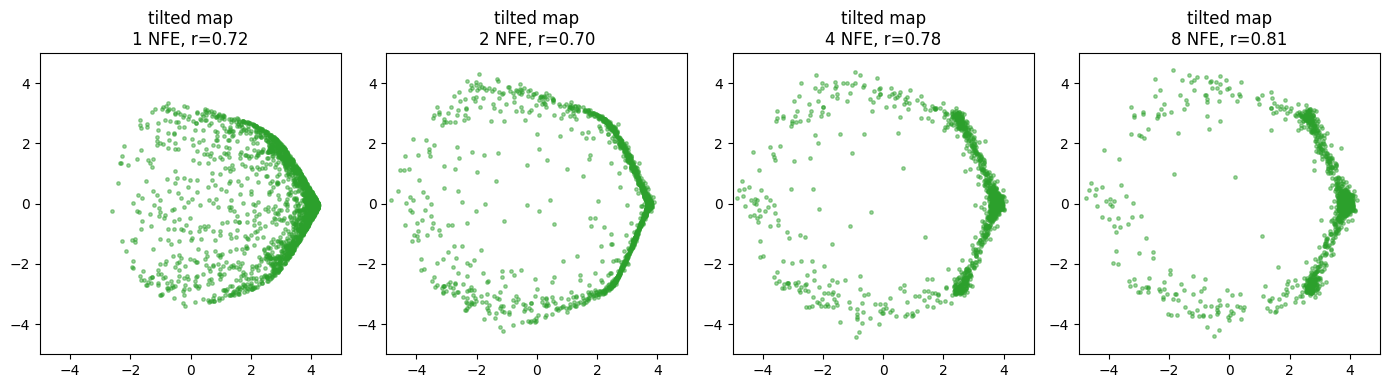

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, nfe in zip(axes, [1, 2, 4, 8]):
    samples = tilted_samples_by_nfe[nfe]
    eval_row = next(e for e in flow_map_reward_evals if e["nfe"] == str(nfe))
    plot_samples(samples[:2000], ax, title=f"tilted map\n{nfe} NFE, r={eval_row['mean_reward']:.2f}", color="C2")
plt.tight_layout()
plt.show()

**Takeaway:** the reward-tilted flow map moves samples toward the rewarded
right side while keeping the same two-time flow-map parameterization. The best
NFE is selected by distance to the tilted target, not by reward alone. This
connects the Flow Map 101 story to reward-alignment methods: once we can learn
few-step maps, reward tilting can be added as another training signal rather
than a completely separate framework.

## 8. Recap

**Velocity model:**

$$
v_\theta(x_t,t)
$$

predicts a local tangent direction. Sampling requires many small steps.

**Flow map:**

$$
F_\phi(x_s,s,t)
$$

predicts where the same path will be at another time. With the average-velocity
parameterization:

$$
F_\phi(x_s,s,t)=x_s+(t-s)V_\phi(x_s,s,t).
$$

**Why it matters:**

* A flow map learns the integral of the velocity field over a time interval.
* This enables few-step sampling.
* Consistency rules make sure different jumps describe one coherent path.
* Many recent reward-alignment papers assume such few-step flow maps as a
  prerequisite.

**What we implemented:**

1. train a 2D flow-matching teacher,
2. define flow maps as finite-time operators,
3. introduce semigroup, Lagrangian, and Eulerian consistency,
4. train Route A teacher-distillation variants: semigroup, LMD, EMD,
5. train Route B self-distillation variants: PSD, LSD, ESD,
6. compare all methods across 1, 2, 4, and 8 NFEs,
7. combine an ITM-style reward-tilting target with a flow-map training loop.